
=== Per-bin Summary (methods side-by-side) ===
 Bin          MAF_range MAF_center Impute5_R2 BERT_R2 Diffusion_R2  Num_SNPs
   1 [0.00419, 0.00559) 4.8418e-03     0.5909  0.4747       0.3137      1345
   2 [0.00559, 0.00779) 6.5987e-03     0.6225  0.5188       0.3539      1375
   3 [0.00779, 0.01138) 9.4150e-03     0.6826  0.5749       0.4273      1456
   4 [0.01138, 0.01697) 1.3899e-02     0.7175  0.5932       0.4730      1382
   5 [0.01697, 0.02895) 2.2168e-02     0.7098  0.6091       0.5219      1394
   6 [0.02895, 0.06150) 4.2199e-02     0.7725  0.6924       0.6103      1411
   7 [0.06150, 0.14317) 9.3837e-02     0.8352  0.7606       0.7209      1397
   8 [0.14317, 0.31130) 2.1111e-01     0.8772  0.8078       0.7830      1394
   9 [0.31130, 0.49960) 3.9437e-01     0.9446  0.9164       0.8948      1397


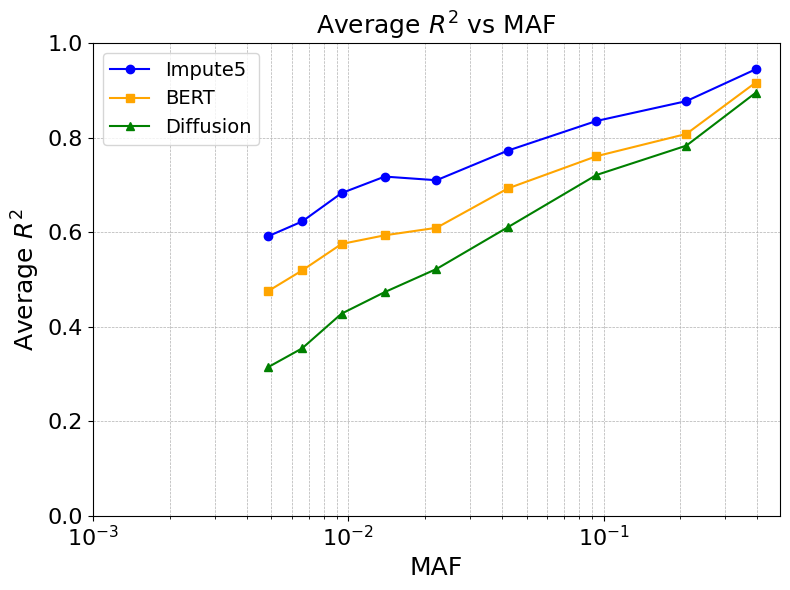

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings ---
num_bins = 9
colors = ['blue', 'orange', 'green', 'red', 'purple']  # extend as needed
markers = ['o', 's', '^', 'x', 'd']                     # extend as needed

# --- Load data ---
impute5 = pd.read_csv(
    "/scratch2/prateek/genetic_pc_github/plots/impute/results/multi/8020_multi_real_b38_hum5_chr15_results.csv"
)[["SNP", "R2", "MAF"]]

bert = pd.read_csv(
    "/scratch2/prateek/DeepLearningImputation/bert/results_b38.csv"
)[["SNP", "R2", "MAF"]]

diff = pd.read_csv(
    "/scratch2/prateek/DeepLearningImputation/diffusion/results/diff_results_bern2_b38.csv"
)[["SNP", "R2", "MAF"]]

# Add more methods here if needed
datasets = [("Impute5", impute5), ("BERT", bert), ("Diffusion", diff)]

# --- Compute quantile-based bins ---
all_maf = pd.concat([df["MAF"] for _, df in datasets])
bin_edges = np.quantile(all_maf, np.linspace(0, 1, num_bins + 1))
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

# --- Prepare summary table ---
summary = pd.DataFrame({
    "Bin": np.arange(1, num_bins + 1),
    "MAF_range": [f"[{bin_edges[i]:.5f}, {bin_edges[i+1]:.5f})" for i in range(num_bins)],
    "MAF_center": bin_centers
})

# --- Compute mean R² and SNP counts per bin for each method ---
for label, df in datasets:
    df["bin"] = np.digitize(df["MAF"], bin_edges) - 1
    df["bin"] = df["bin"].clip(0, num_bins - 1)
    
    mean_r2 = [df.loc[df["bin"] == i, "R2"].mean() for i in range(num_bins)]
    snp_counts = [df.loc[df["bin"] == i, "SNP"].count() for i in range(num_bins)]
    
    summary[f"{label}_R2"] = mean_r2

summary[f"Num_SNPs"] = snp_counts

# --- Print summary table ---
print("\n=== Per-bin Summary (methods side-by-side) ===")
print(summary.to_string(index=False, formatters={
    "MAF_center": "{:.4e}".format,
    **{f"{label}_R2": "{:.4f}".format for label, _ in datasets}
}))

# --- Plot ---
plt.figure(figsize=(8,6))
for (label, df), color, marker in zip(datasets, colors, markers):
    plt.plot(bin_centers, summary[f"{label}_R2"], marker=marker, color=color, label=label)

# --- Formatting ---
plt.xscale('log')
plt.xticks([1e-3, 1e-2, 1e-1], [r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$"], fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('MAF', fontsize=18)
plt.ylabel(r'Average $R^2$', fontsize=18)
plt.ylim(0, 1)
plt.title("Average $R^2$ vs MAF", fontsize=18)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()
